In [3]:
print("House Price Prediction")

House Price Prediction


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sklearn.model_selection 
from sklearn.model_selection import train_test_split



In [10]:
df = pd.read_csv("data/house_prices.csv")

In [11]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [12]:
df.shape

(187531, 21)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [16]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

In [15]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [17]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area', 'carpet_area_sqft', 'floor_num', 'bathroom',
       'balcony', 'car_parking'],
      dtype='str')

In [46]:
df["Price (in rupees)"].head(20)

0      6000.0
1     13799.0
2     17500.0
3         NaN
4     18824.0
5      6618.0
6      2538.0
7     10435.0
8     10000.0
9     11150.0
10    12174.0
11    11674.0
12    15995.0
13    17526.0
14    11538.0
15    10000.0
16     5736.0
17     6481.0
18    11250.0
19     6731.0
Name: Price (in rupees), dtype: float64

In [48]:
df["Carpet Area"].head(20)

0      500 sqft
1      473 sqft
2      779 sqft
3      530 sqft
4      635 sqft
5           NaN
6      550 sqft
7           NaN
8           NaN
9      900 sqft
10     950 sqft
11          NaN
12          NaN
13    1820 sqft
14          NaN
15     675 sqft
16     647 sqft
17          NaN
18     600 sqft
19          NaN
Name: Carpet Area, dtype: str

In [49]:
df["carpet_area_sqft"] = df["Carpet Area"].str.extract(r"([\d.]+)")[0].astype(float)

In [50]:
df[["Carpet Area", "carpet_area_sqft"]].head(10)

,Carpet Area,carpet_area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
5,NaN,NaN
6,550 sqft,550.0
7,NaN,NaN
8,NaN,NaN
9,900 sqft,900.0


In [51]:
df["Floor"].head(20)

0        10 out of 11
1         3 out of 22
2        10 out of 29
3          1 out of 3
4        20 out of 42
5          2 out of 7
6          4 out of 5
7     Ground out of 7
8     Ground out of 2
9         3 out of 27
10        6 out of 20
11       16 out of 24
12        8 out of 20
13       18 out of 27
14         2 out of 3
15       10 out of 16
16         5 out of 7
17         4 out of 5
18       20 out of 28
19         3 out of 3
Name: Floor, dtype: str

In [52]:
df["floor_num"] = df["Floor"].str.extract(r"^(\d+)")[0].astype(float)

df.loc[
    df["Floor"].str.contains("Ground", case=False, na=False),
    "floor_num"
] = 0

In [53]:
df[["Floor", "floor_num"]].head(20)

,Floor,floor_num
0,10 out of 11,10.0
1,3 out of 22,3.0
2,10 out of 29,10.0
3,1 out of 3,1.0
4,20 out of 42,20.0
5,2 out of 7,2.0
6,4 out of 5,4.0
7,Ground out of 7,0.0
8,Ground out of 2,0.0
9,3 out of 27,3.0


In [54]:
df["Bathroom"].head(20)

0     1
1     2
2     2
3     1
4     2
5     1
6     1
7     1
8     1
9     3
10    2
11    2
12    2
13    4
14    1
15    2
16    1
17    1
18    2
19    1
Name: Bathroom, dtype: str

In [55]:
df["bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")

In [56]:
df[["Bathroom", "bathroom"]].head(10)

,Bathroom,bathroom
0,1,1.0
1,2,2.0
2,2,2.0
3,1,1.0
4,2,2.0
5,1,1.0
6,1,1.0
7,1,1.0
8,1,1.0
9,3,3.0


In [57]:
df["Balcony"].head(20)

0       2
1     NaN
2     NaN
3       1
4     NaN
5       1
6     NaN
7     NaN
8     NaN
9       1
10    NaN
11    NaN
12    NaN
13      1
14    NaN
15      1
16      2
17    NaN
18    NaN
19      1
Name: Balcony, dtype: str

In [58]:
df["balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")

In [59]:
df[["Balcony", "balcony"]].head(10)

,Balcony,balcony
0,2,2.0
1,NaN,NaN
2,NaN,NaN
3,1,1.0
4,NaN,NaN
5,1,1.0
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,1,1.0


In [60]:
df["Car Parking"].head(20)

0            NaN
1         1 Open
2      1 Covered
3            NaN
4      1 Covered
5            NaN
6            NaN
7            NaN
8            NaN
9      1 Covered
10        1 Open
11           NaN
12           NaN
13     2 Covered
14           NaN
15     1 Covered
16           NaN
17           NaN
18    66 Covered
19        1 Open
Name: Car Parking, dtype: str

In [61]:
df["car_parking"] = df["Car Parking"].str.extract(r"(\d+)")[0].astype(float)

In [62]:
df[["Car Parking", "car_parking"]].head(20)

,Car Parking,car_parking
0,NaN,NaN
1,1 Open,1.0
2,1 Covered,1.0
3,NaN,NaN
4,1 Covered,1.0
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,1 Covered,1.0


In [63]:
df["location"].value_counts().head(50)

location
new-delhi        27599
bangalore        24030
kolkata          22380
gurgaon          20070
ahmedabad        12750
hyderabad        12300
chennai          10500
jaipur            8490
greater-noida     4710
faridabad         3840
vadodara          2388
surat             2370
pune              2225
thane             1933
mumbai            1860
visakhapatnam     1800
mohali            1710
zirakpur          1530
chandigarh        1440
noida             1281
goa               1200
ranchi            1080
bhiwadi           1050
kochi             1050
dehradun           990
ghaziabad          931
lucknow            896
kanpur             780
patna              780
guwahati           750
sonipat            750
coimbatore         720
navi-mumbai        718
nagpur             714
jamshedpur         630
kalyan             600
vijayawada         570
palghar            510
raipur             510
bhubaneswar        456
agra               450
aurangabad         450
mangalore          450
ba

In [65]:
top_locations = df["location"].value_counts().head(50).index

df["location_grouped"] = df["location"].where(
    df["location"].isin(top_locations),
    "Other"
)

In [66]:
df["location_grouped"].value_counts().head(10)

location_grouped
new-delhi        27599
bangalore        24030
kolkata          22380
gurgaon          20070
ahmedabad        12750
hyderabad        12300
chennai          10500
jaipur            8490
greater-noida     4710
faridabad         3840
Name: count, dtype: int64

In [67]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
car_parking          0.551146
overlooking          0.434254
carpet_area_sqft     0.430185
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
balcony              0.261061
Balcony              0.260944
Price (in rupees)    0.094198
floor_num            0.039668
Floor                0.037738
Description          0.016120
Furnishing           0.015448
bathroom             0.004602
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Title                0.000000
Amount(in rupees)    0.000000
location             0.000000
Index                0.000000
location_grouped     0.000000
dtype: float64

In [68]:
df = df.drop(["Plot Area", "Dimensions"], axis=1)

In [69]:
df = df.dropna(subset=["Price (in rupees)"])

In [70]:
df["Price (in rupees)"].isna().sum()

np.int64(0)

In [71]:
df["Price (in rupees)"].describe()

count    1.698660e+05
mean     7.583772e+03
std      2.724171e+04
min      0.000000e+00
25%      4.297000e+03
50%      6.034000e+03
75%      9.450000e+03
max      6.700000e+06
Name: Price (in rupees), dtype: float64

In [72]:
df = df[df["Price (in rupees)"] > 0]

In [73]:
df["Price (in rupees)"].min()

np.float64(1.0)

In [74]:
df["price_per_sqft"] = (
    df["Price (in rupees)"] / df["carpet_area_sqft"]
)

In [75]:
df["price_per_sqft"].describe()

count    9.362400e+04
mean     3.055143e+01
std      4.903487e+03
min      2.482234e-05
25%      4.458981e+00
50%      6.210227e+00
75%      9.263604e+00
max      1.500000e+06
Name: price_per_sqft, dtype: float64

In [76]:
lower = df["price_per_sqft"].quantile(0.01)
upper = df["price_per_sqft"].quantile(0.99)

print("1st percentile:", lower)
print("99th percentile:", upper)

1st percentile: 1.715592832634388
99th percentile: 154.9301666666672


In [77]:
df = df[
    (df["price_per_sqft"] >= lower) &
    (df["price_per_sqft"] <= upper)
]

In [78]:
df["price_per_sqft"].describe()

count    91893.000000
mean        10.234178
std         14.994606
min          1.715593
25%          4.497857
50%          6.210227
75%          9.263604
max        154.833333
Name: price_per_sqft, dtype: float64

In [79]:
df.isna().mean().sort_values(ascending=False)

Super Area           1.000000
Society              0.481756
Car Parking          0.388223
car_parking          0.388223
overlooking          0.222433
facing               0.161775
Ownership            0.146050
balcony              0.051625
Balcony              0.051603
floor_num            0.025356
Floor                0.022864
Description          0.002938
Status               0.000784
Furnishing           0.000239
bathroom             0.000218
Bathroom             0.000174
Transaction          0.000033
Title                0.000000
Carpet Area          0.000000
Amount(in rupees)    0.000000
Price (in rupees)    0.000000
location             0.000000
Index                0.000000
carpet_area_sqft     0.000000
location_grouped     0.000000
price_per_sqft       0.000000
dtype: float64

In [80]:
df = df.drop("Super Area", axis=1)

In [82]:
df = df.drop([
    "Carpet Area",
    "Floor",
    "Bathroom",
    "Balcony",
    "Car Parking"
], axis=1)

In [83]:
df = df.drop([
    "Index",
    "Title",
    "Description",
    "Amount(in rupees)",
    "Society",
    "overlooking",
    "price_per_sqft"
], axis=1)

In [84]:
df.info()

<class 'pandas.DataFrame'>
Index: 91893 entries, 0 to 187528
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price (in rupees)  91893 non-null  float64
 1   location           91893 non-null  str    
 2   Status             91821 non-null  str    
 3   Transaction        91890 non-null  str    
 4   Furnishing         91871 non-null  str    
 5   facing             77027 non-null  str    
 6   Ownership          78472 non-null  str    
 7   carpet_area_sqft   91893 non-null  float64
 8   floor_num          89563 non-null  float64
 9   bathroom           91873 non-null  float64
 10  balcony            87149 non-null  float64
 11  car_parking        56218 non-null  float64
 12  location_grouped   91893 non-null  str    
dtypes: float64(6), str(7)
memory usage: 9.8 MB


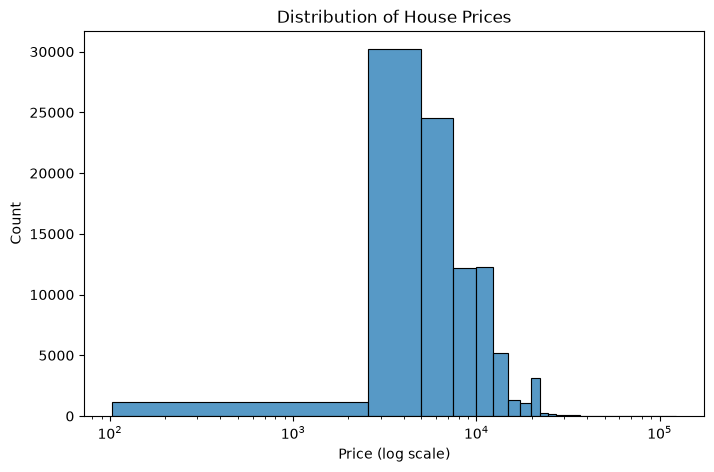

In [85]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Price (in rupees)"],
    bins=50
)

plt.xscale("log")
plt.title("Distribution of House Prices")
plt.xlabel("Price (log scale)")
plt.ylabel("Count")

plt.show()

The price distribution is right-skewed. The log scale makes the distribution easier to visualize because there are some very high-priced properties.

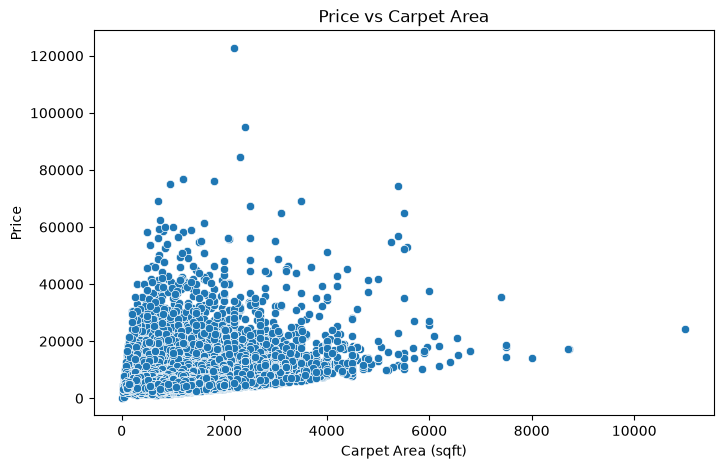

In [86]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="carpet_area_sqft",
    y="Price (in rupees)"
)

plt.title("Price vs Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price")

plt.show()

The scatter plot shows the relationship between carpet area and house price. In general, larger carpet areas tend to have higher prices.

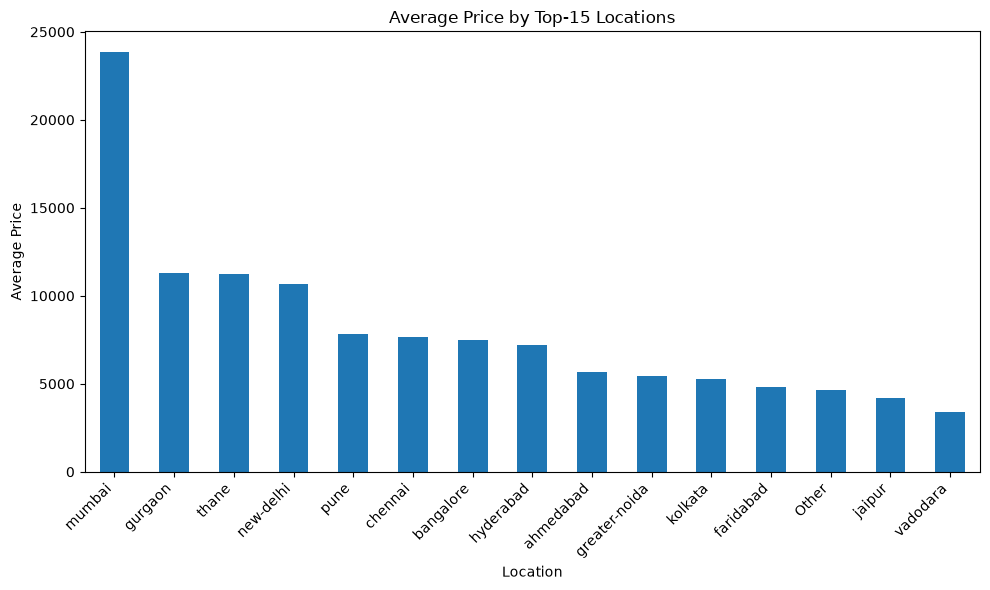

In [87]:
top_15 = df["location_grouped"].value_counts().head(15).index

avg_price = (
    df[df["location_grouped"].isin(top_15)]
    .groupby("location_grouped")["Price (in rupees)"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

avg_price.plot(kind="bar")

plt.title("Average Price by Top-15 Locations")
plt.xlabel("Location")
plt.ylabel("Average Price")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

The bar chart compares the average house price across the top 15 locations. The average price varies between locations, showing that location has an important effect on house prices.

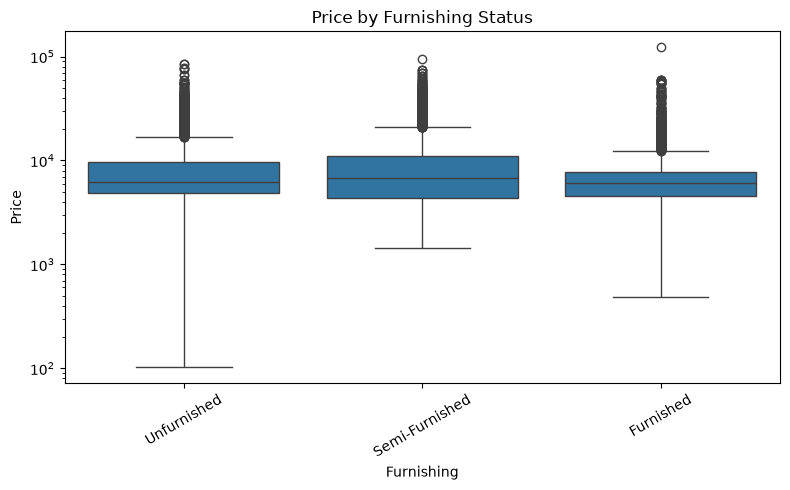

In [88]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="Price (in rupees)"
)

plt.title("Price by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Price")

plt.yscale("log")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

The box plot shows the distribution of house prices for different furnishing statuses. It helps compare the median prices and the spread of prices between furnishing categories.

In [89]:
df.info()

<class 'pandas.DataFrame'>
Index: 91893 entries, 0 to 187528
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price (in rupees)  91893 non-null  float64
 1   location           91893 non-null  str    
 2   Status             91821 non-null  str    
 3   Transaction        91890 non-null  str    
 4   Furnishing         91871 non-null  str    
 5   facing             77027 non-null  str    
 6   Ownership          78472 non-null  str    
 7   carpet_area_sqft   91893 non-null  float64
 8   floor_num          89563 non-null  float64
 9   bathroom           91873 non-null  float64
 10  balcony            87149 non-null  float64
 11  car_parking        56218 non-null  float64
 12  location_grouped   91893 non-null  str    
dtypes: float64(6), str(7)
memory usage: 9.8 MB


In [90]:
df.head()

,Price (in rupees),location,Status,Transaction,Furnishing,facing,Ownership,carpet_area_sqft,floor_num,bathroom,balcony,car_parking,location_grouped
0,6000.0,thane,Ready to Move,Resale,Unfurnished,NaN,NaN,500.0,10.0,1.0,2.0,NaN,thane
1,13799.0,thane,Ready to Move,Resale,Semi-Furnished,East,Freehold,473.0,3.0,2.0,NaN,1.0,thane
2,17500.0,thane,Ready to Move,Resale,Unfurnished,East,Freehold,779.0,10.0,2.0,NaN,1.0,thane
4,18824.0,thane,Ready to Move,Resale,Unfurnished,West,Co-operative Society,635.0,20.0,2.0,NaN,1.0,thane
6,2538.0,thane,Ready to Move,Resale,Unfurnished,NaN,NaN,550.0,4.0,1.0,NaN,NaN,thane


In [91]:
numeric_features = [
    "carpet_area_sqft",
    "floor_num",
    "bathroom",
    "balcony"
]

categorical_features = [
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

X = df[numeric_features + categorical_features]
y = df["Price (in rupees)"]

In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [93]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (73514, 9)
X_test: (18379, 9)
y_train: (73514,)
y_test: (18379,)


In [94]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [95]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),

    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

In [96]:
from sklearn.ensemble import RandomForestRegressor

In [97]:
model_rf = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [98]:
model_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [99]:
from sklearn.linear_model import LinearRegression

In [100]:
model_lr = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

In [101]:
model_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [102]:
pred_rf = model_rf.predict(X_test)
pred_lr = model_lr.predict(X_test)

In [103]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [104]:
print("Random Forest")
print("MAE :", mean_absolute_error(y_test, pred_rf))
print("RMSE:", root_mean_squared_error(y_test, pred_rf))
print("R² :", r2_score(y_test, pred_rf))

Random Forest
MAE : 579.047191049551
RMSE: 1716.0572679161614
R² : 0.8839664523364508


In [105]:
print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, pred_lr))
print("RMSE:", root_mean_squared_error(y_test, pred_lr))
print("R² :", r2_score(y_test, pred_lr))

Linear Regression
MAE : 2039.0659896807047
RMSE: 3160.7789322150306
R² : 0.6063518082904462


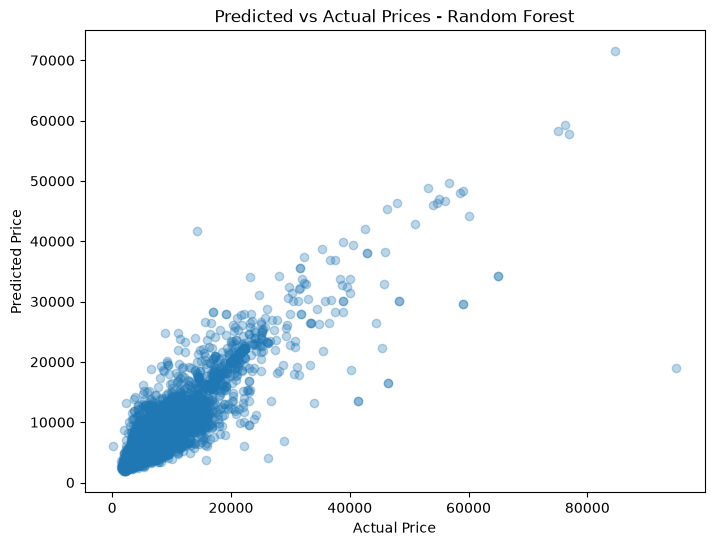

In [106]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, pred_rf, alpha=0.3)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices - Random Forest")

plt.show()

In [107]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Linear Regression"],
    "MAE": [
        mean_absolute_error(y_test, pred_rf),
        mean_absolute_error(y_test, pred_lr)
    ],
    "RMSE": [
        root_mean_squared_error(y_test, pred_rf),
        root_mean_squared_error(y_test, pred_lr)
    ],
    "R2": [
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_lr)
    ]
})

results

,Model,MAE,RMSE,R2
0,Random Forest,579.047191,1716.057268,0.883966
1,Linear Regression,2039.065990,3160.778932,0.606352


Random Forest was selected as the best model because it achieved the lowest MAE and RMSE and the highest R² score. It achieved an R² of about 0.884, compared with 0.606 for Linear Regression. Therefore, Random Forest provides more accurate predictions for house prices on the test set.

In [108]:
import joblib

In [109]:
joblib.dump(model_rf, "house_price.pkl")

['house_price.pkl']

In [110]:
loaded = joblib.load("house_price.pkl")

sample = X_test.iloc[[0]]

print("Reloaded prediction:", loaded.predict(sample))

Reloaded prediction: [6000.]


In [111]:
import json

json.dump(
    sorted(df["location_grouped"].unique().tolist()),
    open("locations.json", "w")
)

In [112]:
import sklearn

print(sklearn.__version__)

1.9.0
